In [2]:
from dotenv import load_dotenv
import os
load_dotenv()

if os.getenv("GROQ_API_KEY") is None:
    raise ValueError("GROQ_API_KEY is not set")
else:
    print("GROQ_API_KEY is set")

GROQ_API_KEY is set


In [3]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model_name="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY"),
)
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x7f3285a40ec0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7f3285a41be0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

## **LLM Pydantic Schema**

In [4]:
from pydantic import BaseModel, Field
from typing import Literal

class llm_schema(BaseModel):
    category: Literal["instagram", "linkedin", "twitter"]
    topic:str = Field(description = "The topic of the post to generate")

In [5]:
llm_with_schema = llm.with_structured_output(llm_schema)
llm_with_schema.invoke("Create a post for instagram about Geopolitical tensions")

llm_schema(category='instagram', topic='Geopolitical tensions')

In [14]:
print(llm_with_schema.invoke("Create a post for job opening for a Data Engineer"))
print(llm_with_schema.invoke("Create a caption for a reel for on wedding photo"))
print(llm_with_schema.invoke("Create a post on geopolitical tensions"))

# We saw that the LLM is able to generate the post for the given topic, it is able to decide which category to use based on the topic.

category='linkedin' topic='job opening for Data Engineer'
category='instagram' topic='wedding photo caption'
category='linkedin' topic='geopolitical tensions'


In [15]:
from typing import TypedDict, List

class graph_schema(TypedDict):
    input:str
    topic:str
    post:str
    category:str



## Let's create a decider node

In [16]:
def decider_node(state:graph_schema)->graph_schema:

    user_input = state["input"]

    #Passing user input to the LLM to decide the category
    response = llm_with_schema.invoke(user_input)
    category = response.category
    topic = response.topic

    state["category"] = category
    state["topic"] = topic

    return state

## Now, we will create three nodes for each of the social media platform.

## Now, we will create three nodes for each of the social media platform.

In [21]:
def create_insta_post(state:graph_schema)->graph_schema:

    topic = state["topic"]

    post = llm.invoke(f"Create a post for instagram about {topic}. Keep the tone very funny, casual and engaging under 100 words.")

    state["instagram"] = post

    return {"instagram":post}

def create_linkedin_post(state:graph_schema)->graph_schema:

    topic = state["topic"]

    post = llm.invoke(f"Create a post for linkedin about {topic}. Keep the tone very professional, formal and engaging under 100 words.")
    
    state["linkedin"] = post

    return {"linkedin":post}

def create_twitter_post(state:graph_schema)->graph_schema:

    topic = state["topic"]

    post = llm.invoke(f"Create a post for twitter about {topic}. Keep the tone very casual, harsh and engaging and under 100 words.")

    state["twitter"] = post

    return {"twitter":post}

## Now, we will create a graph for the parallel execution of the nodes.



In [26]:
def condition(state: graph_schema) -> str:
    category = state["category"]

    # Return router labels expected by add_conditional_edges mapping.
    if category == "instagram":
        return "instagram"
    elif category == "linkedin":
        return "linkedin"
    elif category == "twitter":
        return "twitter"
    else:
        raise ValueError(f"Invalid category: {category}")


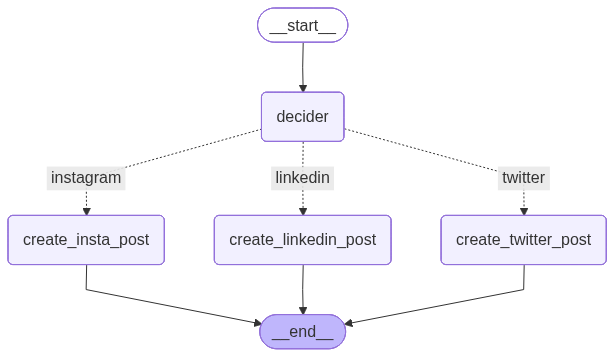

In [27]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("decider", decider_node)
graph.add_node("create_insta_post", create_insta_post)
graph.add_node("create_linkedin_post", create_linkedin_post)
graph.add_node("create_twitter_post", create_twitter_post)

graph.add_edge(START, "decider")
graph.add_conditional_edges("decider", condition, {"instagram":"create_insta_post", "linkedin":"create_linkedin_post", "twitter":"create_twitter_post"})

graph.add_edge("create_insta_post", END )
graph.add_edge("create_linkedin_post", END)
graph.add_edge("create_twitter_post", END)

router_graph = graph.compile()

from IPython.display import Image, display

Image(router_graph.get_graph().draw_mermaid_png())

In [28]:
router_graph.invoke({"input":"Create a post for my wedding announcement in very fun way."})

{'input': 'Create a post for my wedding announcement in very fun way.',
 'topic': 'fun wedding announcement post',
 'category': 'instagram'}

In [29]:
router_graph.invoke({"input":"Create a post for my job switch to a new role."})

{'input': 'Create a post for my job switch to a new role.',
 'topic': 'job switch to a new role',
 'category': 'linkedin'}

In [30]:
router_graph.invoke({"input":"Create a post for my views on geopolitical tensions."})

{'input': 'Create a post for my views on geopolitical tensions.',
 'topic': 'geopolitical tensions',
 'category': 'twitter'}